# ICS 2405: Knowledge-Based Systmes

## deconstucting error into bias and variance:
> evaluationg models continued

#### variance:
the degree to which data is affected by randomness is called the *variance of the data*.  
the way models vary due to the random selection of the data(depends on the training and testing datasets) we train on is called the **variance of the model**.  

#### bias of the model:
in this context noise is the inherent randomnes in the dataset that needs to be eliminated

#### salient
> this follows the technical way to look at bias and variance
*   **sources of prediction error:** there are three fundamental components:
    *   **bias:** the error from a model's inability to represent the true underlying relationship (e.g., using addition when the true link is multiplication). learning the wrong relationship picked from noisy data  
    *   **variance (model):** the error from a model's sensitivity to the specific training data it was built on.
    *   **variance (data):** the inherent, irreducible noise or randomness in the data itself.

*   **the bias-variance tradeoff:** adjusting a model's complexity creates a tradeoff:
    *   **high bias / low variance:** simpler models (e.g., high *k* in k-NN, linear regression with few features) are stable and resist noise but may miss important patterns (**underfitting**).
    *   **low bias / high variance:** complex models (e.g., low *k* in k-NN, high-degree polynomials) can fit intricate patterns but also fit random noise, leading to unstable predictions (**overfitting**).

*   **model-specific tradeoffs:**
    *   **k-Nearest Neighbors:** increasing *k* (neighbors) **increases bias but decreases variance**.
    *   **Linear Regression:** adding more features or polynomial terms **decreases bias but increases variance**.
    *   **Naive Bayes:** the method sits at a high-bias, low-variance point on a spectrum of possible dependency assumptions.

*   **wraps:** at their simplest, many models (k-NN with all data, linear regression with only an intercept, an extremely naive classifier) all reduce to predicting the overall mean/mode, which is their highest-bias starting point.

In [1]:
# setup
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import (datasets, model_selection as skms, linear_model, metrics, neighbors, naive_bayes)

## learning curves:
> how much data do we need?
>

*   **`learning curves`** plot model performance (accuracy) against the amount of training data used. they help answer:
    *   **"do we need more data?"** if the test score keeps improving, more data may help.
    *   **"is the model any good?"** if performance plateaus at a low level, the model may be fundamentally unsuitable.

sklearn provides `learning_curve`:

In [2]:
iris = datasets.load_iris()
# 10 data set sizes: 10% - 100%
# (that much data is piped to a 5-fold CV)
train_sizes = np.linspace(.1, 1.0, 10)
nn = neighbors.KNeighborsClassifier()

(train_N, train_scores, test_scores) = skms.learning_curve(nn, iris.data, iris.target, cv=5, train_sizes=train_sizes)

# collapse across the 5 CV scores; one result for each data set size
df = pd.DataFrame(test_scores, index=(train_sizes*100).astype(int))
df['Mean 5-CV'] = df.mean(axis='columns')
df.index.name = "% Data Used"
display(df)

,0,1,2,3,4,Mean 5-CV
% Data Used,,,,,,
10,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
20,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
30,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
40,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
50,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
60,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
70,0.900000,0.800000,0.833333,0.866667,0.800000,0.840000
80,0.966667,0.933333,0.900000,0.900000,0.966667,0.933333
90,0.966667,1.000000,0.900000,0.966667,1.000000,0.966667


`learning_curve` returns arrays with two dimensions: the **number of training sizes** by
the **number of cv-folds**. eg (10, 5) and we can plot/visualize this

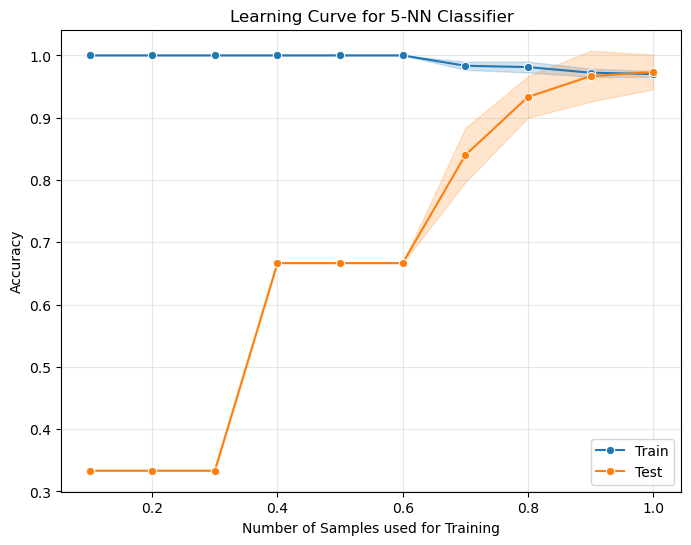

In [3]:
# tsplot(deprecated) expects array data to have these dimensions:
# (repeats, times, conditions)
# for us, those translate to:
# (CV scores, percents, train/test)
joined = np.array([train_scores, test_scores]).transpose()

# reshape data for plotting
# create tidy dataframe format
data_list = []
for cond_idx, cond_name in enumerate(['Train', 'Test']):
    for size_idx, size in enumerate(train_sizes):
        for fold_idx in range(joined.shape[0]):
            data_list.append({
                'Training Size': size,
                'Score': joined[fold_idx, size_idx, cond_idx],
                'Condition': cond_name,
                'Fold': fold_idx
            })

df = pd.DataFrame(data_list)

# plot using lineplot instead of tsplot
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x='Training Size', y='Score', hue='Condition', 
             estimator='mean', errorbar='sd', marker='o')
plt.title("Learning Curve for 5-NN Classifier")
plt.xlabel("Number of Samples used for Training")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show();

### complexity curves:


*   **complexity (validation) curves** plot performance against a model's complexity parameter (e.g., *k* in k-NN).
    *   They visualize the **bias-variance tradeoff**. low complexity (high *k*) leads to high bias/underfitting; high complexity (low *k*) leads to high variance/overfitting.
    *   the optimal model is often where the **test performance peaks**, balancing underfitting and overfitting. in the iris case(below), this occurred around *k*=10.

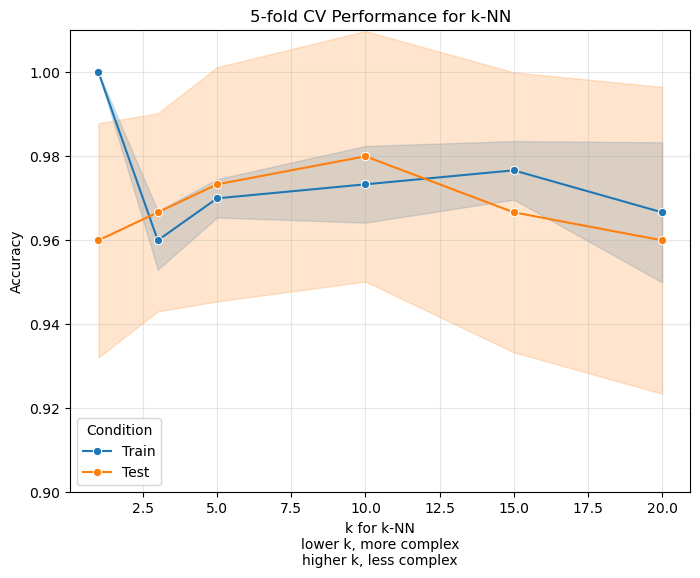

In [4]:
num_neigh = [1, 3, 5, 10, 15, 20]

KNC = neighbors.KNeighborsClassifier
tt = skms.validation_curve(KNC(), iris.data, iris.target, param_name='n_neighbors', param_range=num_neigh, cv=5)

# tt is a tuple (train_scores, test_scores)
# Convert to array and transpose to get shape (CV folds, param_values, train/test)
tt_array = np.array(tt).transpose()

# Reshape data for plotting
data_list = []
for cond_idx, cond_name in enumerate(['Train', 'Test']):
    for param_idx, param_val in enumerate(num_neigh):
        for fold_idx in range(tt_array.shape[0]):
            data_list.append({
                'k': param_val,
                'Score': tt_array[fold_idx, param_idx, cond_idx],
                'Condition': cond_name,
                'Fold': fold_idx
            })

df = pd.DataFrame(data_list)

# Plot using lineplot instead of tsplot
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x='k', y='Score', hue='Condition',
             estimator='mean', errorbar='sd', marker='o')
plt.title('5-fold CV Performance for k-NN')
plt.xlabel("\n".join(['k for k-NN', 'lower k, more complex', 'higher k, less complex']))
plt.ylim(.9, 1.01)
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

#### comparing learners with cross-validation:

*   **direct model comparison** can be done by plotting the **fold-by-fold CV scores** for different learners.
    *   this reveals **variability** and which model wins on specific data subsets, offering more insight than just comparing average scores.
    *   the example/below shows 5-NN and Gaussian Naive Bayes had similar overall performance, but 5-NN won on more individual folds.

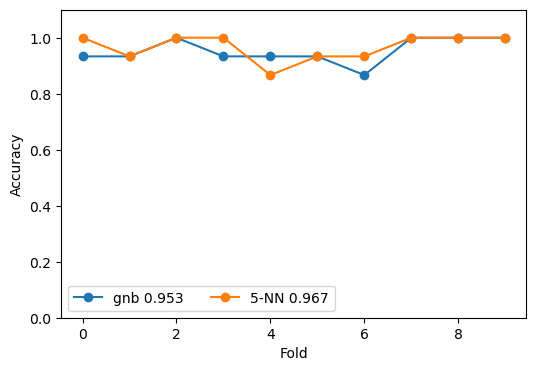

In [5]:
classifiers = {'gnb' : naive_bayes.GaussianNB(),'5-NN' : neighbors.KNeighborsClassifier(n_neighbors=5)}

iris = datasets.load_iris()

fig, ax = plt.subplots(figsize=(6, 4))
for name, model in classifiers.items():
    cv_scores = skms.cross_val_score(model,iris.data, iris.target,cv=10, scoring='accuracy', n_jobs=-1) # use all 

    my_lbl = "{} {:.3f}".format(name, cv_scores.mean())
    ax.plot(cv_scores, '-o', label=my_lbl) # marker=next(markers)

ax.set_ylim(0.0, 1.1)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend(ncol=2);

*   **wraps: (1-NN puzzle):** 1-NN achieves 100% training accuracy because each point is its own nearest neighbor, perfectly memorizing the training set. this is extreme overfitting and only works if the data has no noise.

In [6]:
diabetes = datasets.load_diabetes()

##### a 5-fold CV with sklearn:  

In [7]:
# data, model, fit & cv-score
model = neighbors.KNeighborsRegressor(10)
skms.cross_val_score(model, diabetes.data, diabetes.target, cv=5, scoring='neg_mean_squared_error')
# notes:
# defaults for cross_val_score are
# cv=3 fold, no shuffle, stratified if classifier
# model.score by default (regressors: r2, classifiers: accuracy)

array([-3206.7541573 , -3426.43134831, -3587.94215909, -3039.49443182,
       -3282.60159091])

### end
> more:  
> see notebook on each [classification, regression - specifics directory 4)